📥 Datos cargados: 243 registros MIPYMES, 24 registros Online
⚠️  Excluyendo 'Huevos' de la comparativa (unidades incomparables)
📊 Calculando promedios...
📋 Productos en MIPYMES: 11
📋 Productos en Online: 11
✅ Productos comunes para comparar: 11


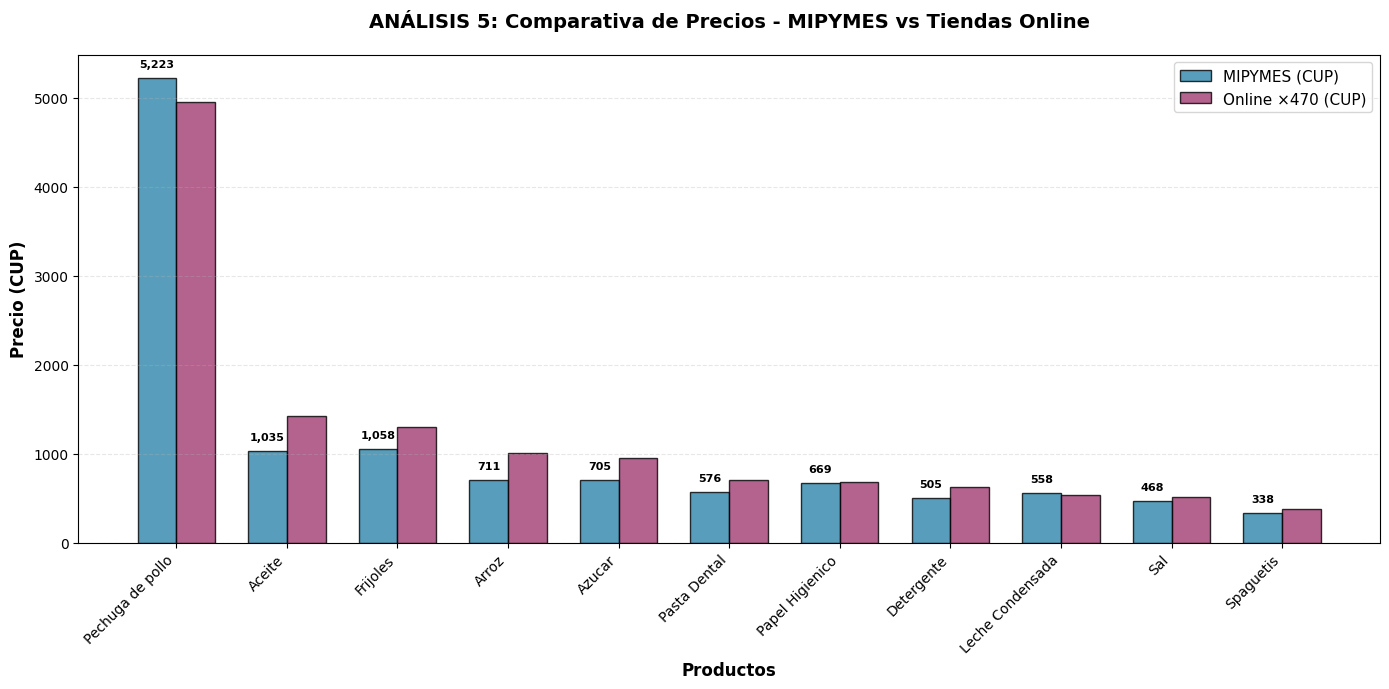

In [2]:

import sys
sys.path.append('../Src')
import matplotlib.pyplot as plt
import numpy as np
import A5 as a5


comparativa = a5.generar_comparativa(
    ruta_mipymes='../Data/Procesados/productos_planos.json',
    ruta_online='../Data/Procesados/online_planos.json',
    tasa_cambio=470
)

# Calcular estadísticas
diferencias = [p['diferencia'] for p in comparativa]
ratios = [p['ratio'] for p in comparativa]

# Preparar datos para gráfico
productos = [p['nombre'] for p in comparativa]
mipyme = [p['mipyme_cup'] for p in comparativa]
online = [p['online_cup'] for p in comparativa]

# Ordenar por precio online para mejor visualización
datos_ordenados = sorted(zip(productos, mipyme, online),
                         key=lambda x: x[2], reverse=True)
productos_ord, mipyme_ord, online_ord = zip(*datos_ordenados)

# Crear gráfico
x = np.arange(len(productos_ord))
ancho = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

# Barras
barras_m = ax.bar(x - ancho/2, mipyme_ord, ancho,
                  label='MIPYMES (CUP)', color='#2E86AB', alpha=0.8, edgecolor='black')
barras_o = ax.bar(x + ancho/2, online_ord, ancho,
                  label='Online ×470 (CUP)', color='#A23B72', alpha=0.8, edgecolor='black')

# Personalización
ax.set_xlabel('Productos', fontsize=12, fontweight='bold')
ax.set_ylabel('Precio (CUP)', fontsize=12, fontweight='bold')
ax.set_title('ANÁLISIS 5: Comparativa de Precios - MIPYMES vs Tiendas Online',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(productos_ord, rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Añadir etiquetas a barras
for bar in barras_m:
    height = bar.get_height()
    if height < 50000:  # Limitar para mejor visualización
        ax.text(bar.get_x() + bar.get_width()/2, height + 100,
                f'{height:,.0f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

# Destacar productos con mayor ratio
for i, prod in enumerate(comparativa):
    if prod['ratio'] > 10:  # Destacar productos >10x más caros online
        # Encontrar índice en lista ordenada
        idx = productos_ord.index(prod['nombre'])
        ax.text(idx, prod['online_cup'] * 0.5, f"{prod['ratio']:.1f}x",
                ha='center', va='center', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='red', alpha=0.2))

plt.tight_layout()
plt.show()

# Encontrar producto con mayor y menor diferencia
max_diff = max(comparativa, key=lambda x: x['diferencia'])
min_diff = min(comparativa, key=lambda x: x['diferencia'])

# Contar productos por categoría de ratio
cat_1_5 = sum(1 for r in ratios if r <= 5)
cat_5_10 = sum(1 for r in ratios if 5 < r <= 10)
cat_10_plus = sum(1 for r in ratios if r > 10)